In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage
from typing import TypedDict, Sequence, Annotated
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain.tools import tool
import requests, os
import sqlite3

load_dotenv()

d:\Programming\GenAI\demo-langgraph\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

In [ ]:
JOKES_API_KEY = os.getenv("JOKES_API_KEY")

In [4]:
# By using the sqlite checkpointer, we can persist checkpoints to a local SQLite database. This allows us to retrieve the conversation state even after the application has been restarted.
sql_conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
checkpointer = SqliteSaver(sql_conn)

In [5]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [6]:
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')

In [7]:
@tool(name_or_callable='get_random_joke', description='Use this tool to get a random joke')
def get_random_joke() -> str:
    print("#### TOOL CALLED: 'get_random_joke' ####")
    res = requests.get(
        "https://api.api-ninjas.com/v1/jokes",
        headers={"X-Api-Key": JOKES_API_KEY}
    ).json()

    return res

# get_random_joke.invoke({})

In [8]:
tools = [get_random_joke]
llm_with_tools = llm.bind_tools(tools)

In [9]:
def llm_node(state: AgentState) -> AgentState:
    res = llm_with_tools.invoke(state['messages'])
    return {'messages': [res]}

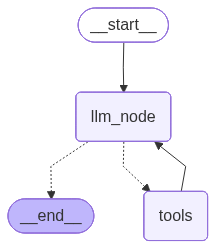

In [10]:
graph = StateGraph(AgentState)

graph.add_node('llm_node', llm_node)
graph.add_node('tools', ToolNode(tools))

graph.add_edge(START, 'llm_node')
graph.add_conditional_edges(
    'llm_node',
    tools_condition
)
graph.add_edge('tools', 'llm_node')

app = graph.compile(checkpointer=checkpointer)

app

In [11]:
config = {
    'configurable': {
        'thread_id': 'agent_thread_1'
    }
}

In [11]:
messages = []
while True:
    user_input = input("User: ")
    if user_input.lower() == "exit":
        break
    messages.append(HumanMessage(content=user_input))
    result = app.invoke({'messages': messages}, config=config)

    print(f"AI: {StrOutputParser().invoke(result['messages'][-1])}")
    messages.append(result['messages'][-1])

AI: Yes, that's right! You are Mainak. How can I help you today?


In [ ]:
# After the conversation, we can retrieve the final state from the database using the same configuration
final_state = app.get_state(config=config)
print(final_state)

StateSnapshot(values={'messages': [HumanMessage(content='Hi, my name is Mainak', additional_kwargs={}, response_metadata={}, id='1694916e-707c-4daa-9452-be8c57c29a00'), AIMessage(content=[{'type': 'text', 'text': "Hello, Mainak! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHk+rgX87q3ohpnGqEki//5odT3RsjYPKmivNV8GTxwDExl7VcUaJDjoJhAboI'}}], additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--21e74b39-310d-4225-a2e7-b4d20e6400cd-0', usage_metadata={'input_tokens': 31, 'output_tokens': 28, 'total_tokens': 59, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='Do u know my name?', additional_kwargs={}, response_metadata={}, id='36c4f495-0854-4e1f-9e6f-7af0de78972f'), AIMessage(content=[{'type': 'text', 'text'

In [ ]:
# List all checkpoints for the given configuration
for chkpnt in checkpointer.list(config=config):
    print(f"Checkpoint: {chkpnt}")